# 05 - Experimentacion general

Esta carpeta separa pruebas laterales y descartes para que la historia principal no quede saturada. El objetivo es mostrar que hubo exploracion y criterio de descarte.


In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'sample_submission.csv').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('No pude encontrar la raiz del repo')
    ROOT = ROOT.parent

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

pd.set_option('display.max_colwidth', 120)

RESULTS = ROOT / '05_experimentacion_general' / 'results'
FIGURES = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
log_path = ROOT / 'investigation' / 'results' / 'experiment_log.csv'
experiment_log = pd.read_csv(log_path)
experiment_log['private_lb_num'] = pd.to_numeric(experiment_log['private_score'], errors='coerce')
print(f'experimentos registrados: {len(experiment_log)}')
recent_view = experiment_log[['run_name', 'date', 'private_score', 'decision']].tail(8).copy()
display(recent_view)


experimentos registrados: 31


,run_name,date,private_score,decision
23,parallel100_e100_headsep_f1024_pair_equal,2026-07-02,0.65605,discard
24,parallel100_e100_headsep20_globalmel40_f1024_40,2026-07-02,0.67113,keep
25,parallel100_e100_headsep15_globalmel425_f1024_425,2026-07-02,0.66928,discard
26,parallel100_e100_headsep25_globalmel375_f1024_375,2026-07-02,0.67126,keep
27,parallel100_globalmel_seed123_replacement,2026-07-02,0.67051,discard
28,parallel100_globalmel_seed_bagging,2026-07-02,0.67528,keep
29,parallel100_f1024_seed123_replacement,2026-07-02,0.66735,discard
30,parallel100_globalmel_f1024_seed_bagging,2026-07-02,0.67674,keep


## Familias de pruebas laterales

Algunas ideas fueron utiles como diagnostico, pero no quedan en el modelo final porque agregan complejidad, no trasladan mejora a Kaggle o son menos defendibles.


In [2]:
general_rows = [
    {'family': 'TTA temporal', 'example': 'theory_tta1024_sep_temporal', 'decision': 'discard', 'reason': 'no traslado mejora al leaderboard'},
    {'family': 'MC Dropout', 'example': 'theory_mcdrop20_sep_temporal', 'decision': 'blend-only', 'reason': 'mejora marginal pero queda superado'},
    {'family': 'SE blocks', 'example': 'theory_sepres_se_head256', 'decision': 'blend-only', 'reason': 'aporta evidencia, pero no entra al final simple'},
    {'family': 'row_z / row_rank', 'example': 'geron_transform_combo_rowz_rowrank', 'decision': 'blend-only', 'reason': 'mejora local, empeora Kaggle'},
    {'family': 'pares incompletos e100', 'example': 'headsep+globalmel / globalmel+f1024', 'decision': 'discard', 'reason': 'sirven para diagnostico; los tres bloques son necesarios'},
]
general = pd.DataFrame(general_rows)
general.to_csv(RESULTS / 'experimentos_generales_resumen.csv', index=False)
display(general)


,family,example,decision,reason
0,TTA temporal,theory_tta1024_sep_temporal,discard,no traslado mejora al leaderboard
1,MC Dropout,theory_mcdrop20_sep_temporal,blend-only,mejora marginal pero queda superado
2,SE blocks,theory_sepres_se_head256,blend-only,"aporta evidencia, pero no entra al final simple"
3,row_z / row_rank,geron_transform_combo_rowz_rowrank,blend-only,"mejora local, empeora Kaggle"
4,pares incompletos e100,headsep+globalmel / globalmel+f1024,discard,sirven para diagnostico; los tres bloques son necesarios


,decision,count
0,keep,14
1,discard,10
2,blend-only,6
3,needs-rerun,1


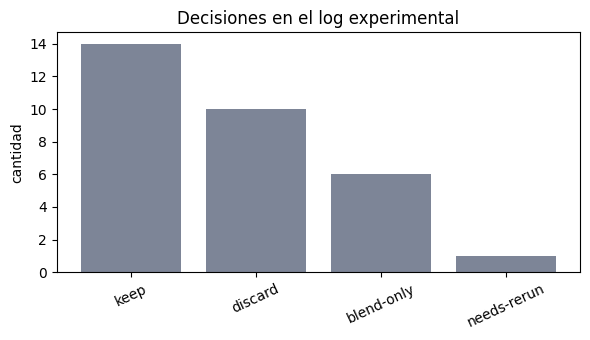

In [3]:
counts = experiment_log['decision'].fillna('sin_decision').value_counts().rename_axis('decision').reset_index(name='count')
counts.to_csv(RESULTS / 'decision_counts.csv', index=False)
display(counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(counts['decision'], counts['count'], color='#7d8597')
ax.set_title('Decisiones en el log experimental')
ax.set_ylabel('cantidad')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIGURES / 'decision_counts.png', dpi=160)
plt.show()


## Conclusion

La experimentacion general queda como soporte de criterio: se probaron variantes, se midieron y varias se descartaron. La entrega no usa esas pruebas como narrativa central.
